In [1]:
import os
os.listdir('.')

['memory',
 ' v6 — Binding Context Document.pdf',
 '.kernel_llm_logs_1.txt',
 '.config',
 '.prompts']

In [2]:

# Plan:
# 1. Define S_k(t) = sum_{n<=N} 1/(n^{1/2+it}) * (some weight)? Actually S_k typically refers to 
# truncated Dirichlet partial sums for ζ. In this context "S_k" likely refers to partial sums
# of the Dirichlet series indexed by k. Let me re-read.
# 
# Looking at the document: "covariance matrix of the real parts of S_k for the Riemann zeta"
# In the context of the binding doc, S_k is likely partial sums S_k(t) = sum_{n=1}^{k} n^{-1/2-it}
# evaluated at various t. The "covariance matrix" Cov(Re S_j, Re S_k) has dimensions over indices j,k 
# representing different truncation lengths or different function classes.
#
# Wait - rereading: "covariance matrix of the real parts of S_k" — the k indexes columns, 
# but Cov(Re S_j, Re S_k) suggests it's the covariance between partial sums at different truncation lengths
# (or different t samples).
#
# Looking again: Step 0.3 mentions "covariance matrix Cov(Re S_j, Re S_k) for ζ at N={10^5, 10^6}
# over t∈[10^4, 2·10^4]". 
# 
# So we evaluate the partial sums S_N(t) = sum_{n=1}^N n^{-1/2-it} over a grid of t values.
# The (j,k) covariance is over different j,k values which are indices.
# 
# Most natural interpretation: S_k is the partial sum truncated at k (so S_1, S_2, ..., S_N).
# Then Cov(Re S_j, Re S_k) is computed over the t samples in [10^4, 2·10^4].
# This gives an N×N covariance matrix.
#
# But N=10^6 would give a 10^6 x 10^6 covariance matrix which is infeasible.
# 
# Alternative: S_k could refer to S_k = sum at dyadic block k, i.e. S_k = sum over n in [2^k, 2^{k+1})
# of n^{-1/2-it}. Then there are ~log_2(N) ~ 17-20 dyadic blocks for N=10^6.
# That seems more reasonable.
#
# Given the 67% claim and bootstrap, I believe S_k refers to dyadic block partial sums.
# Let me go with this interpretation and report it clearly.
print("interpreting S_k as dyadic block partial sums")


interpreting S_k as dyadic block partial sums


In [3]:

# Good. I'll use dyadic block partial sums.
# 
# Plan:
# 1. For ζ(s) at s = 1/2 + it, compute dyadic block partial sums S_k(t) = sum_{n in [2^k, 2^{k+1})} n^{-1/2-it}
# using Kahan summation (R6).
# 2. Sample t values densely in [10^4, 2·10^4]. The Selberg mean spacing of zeros at height T
# is 2π/log(T). T ≈ 1.5e4, so spacing ≈ 2π/log(1.5e4) ≈ 0.65. We want many samples.
# Use a fine grid that resolves this spacing.
# 3. Compute Re S_k(t_i) for all k, i. Then covariance matrix Cov(Re S_j, Re S_k) over t.
# 4. Note R5: unconditional covariances vanish to leading order. So the question is about the
# sub-leading signed bias. Report % negative off-diagonals.
# 5. Block bootstrap with B=200 and block length L_block = 2π/log(T).
# 
# Let me first check: At N=10^6, we have dyadic blocks for k=0..19 (since 2^19 = 524288, 2^20 = 1048576).
# So K ≈ 20 blocks. Off-diagonal entries: K*(K-1) = 380 entries.

import numpy as np
import math
print("Plan ready. Setting up.")


Plan ready. Setting up.


In [4]:

import numpy as np
from numba import njit

@njit(cache=True, fastmath=False)
def dyadic_block_sums_kahan(t_array, N):
 """
 For each t in t_array, compute S_k(t) = sum_{n in [2^k, min(2^(k+1),N+1))} n^{-1/2-it}
 using Kahan compensated summation. Returns complex array shape (len(t_array), K)
 where K = floor(log2(N)) + 1.
 """
 K = 0
 p = 1
 while p <= N:
 K += 1
 p *= 2
 # K is number of dyadic blocks (blocks indexed k=0..K-1, block k covers [2^k, 2^(k+1)) ∩ [1,N])
 
 nT = t_array.shape[0]
 out_re = np.zeros((nT, K))
 out_im = np.zeros((nT, K))
 
 for i in range(nT):
 t = t_array[i]
 for k in range(K):
 lo = 1 << k # 2^k
 hi = 1 << (k+1) # 2^(k+1)
 if hi > N + 1:
 hi = N + 1
 # Kahan sum for real and imag parts
 sum_re = 0.0
 c_re = 0.0
 sum_im = 0.0
 c_im = 0.0
 for n in range(lo, hi):
 # n^{-1/2 - it} = n^{-1/2} * (cos(t log n) - i sin(t log n))
 logn = math.log(n)
 inv_sqrt = 1.0 / math.sqrt(n)
 re = inv_sqrt * math.cos(t * logn)
 im = -inv_sqrt * math.sin(t * logn)
 # Kahan add
 y = re - c_re
 tt = sum_re + y
 c_re = (tt - sum_re) - y
 sum_re = tt
 y = im - c_im
 tt = sum_im + y
 c_im = (tt - sum_im) - y
 sum_im = tt
 out_re[i, k] = sum_re
 out_im[i, k] = sum_im
 return out_re, out_im

# Quick test
t_test = np.array([1.0, 2.0, 3.0])
re, im = dyadic_block_sums_kahan(t_test, 100)
print("shape:", re.shape, "K =", re.shape[1])
print("ζ-partial-sum (sum over k) at t=1:", re[0].sum() + 1j * im[0].sum())
# Compare with mpmath
import mpmath as mp
mp.mp.dps = 30
ref = sum(mp.mpc(n)**mp.mpc(-0.5, -1.0) for n in range(1,101))
print("Reference:", complex(ref))


shape: (3, 7) K = 7
ζ-partial-sum (sum over k) at t=1: (-8.243441423570452+2.4485030340825222j)
Reference: (-8.243441423570454+2.4485030340825227j)


In [5]:

# Excellent. Kahan summation works and matches mpmath to ~15 digits.
# 
# Now plan computation:
# - t in [10^4, 2*10^4], length 10^4. Selberg spacing 2π/log(1.5e4) ≈ 0.652.
# - We want enough t-samples for stable covariance. Use spacing of ~0.1 (so 10^5 samples).
# - At N=10^5: 10^5 inner iterations × 10^5 outer = 10^10 ops. Too much.
# - Need to reduce. Options:
# (a) Use fewer t samples
# (b) Use vectorized numpy for inner loop instead of per-n Kahan
# 
# Actually, Kahan compensated summation is critical only for big inner sums. The key blocks
# at N=10^6 have up to 524288 terms — so Kahan matters there.
# 
# Let's choose:
# - t-grid step = 2π/log(T) / 8 ≈ 0.08, giving ~125,000 samples. Hmm too many.
# - Use step ≈ 0.5 (slightly under spacing) to get 20,000 samples.
# 
# But for bootstrap we need many samples within a block. Block length is one Selberg spacing
# 2π/log(T). With step 0.05, that's ~13 t-points per block.
# 
# Cost at N=10^6: ~10^6 × 20,000 = 2*10^10. Too slow in Python even with numba.
# 
# Better strategy: vectorize over t for each n. 
# At fixed n: contribute n^{-1/2} exp(-it log n) to each t. Use numpy broadcast.
# But Kahan in vectorized form on real array — Kahan needs per-element bookkeeping.
# 
# Trade-off: For N=10^5, naive double precision is probably OK (error ~ N * eps ~ 10^-11).
# For N=10^6, can be borderline (error ~ 10^-10), but for the covariance (which involves
# differences of order O(1)), this should still be fine.
# 
# Let me use vectorized double-precision summation per dyadic block. R6 says use Kahan
# at N>=10^5 because it corrupts GEV fits and conditional moments. For raw partial sums and
# covariance of Re parts, naive should still be very accurate. But to honor R6, I'll use 
# pairwise summation via numpy (not naive) and verify against Kahan on a small subset.

import numpy as np

def dyadic_block_sums_vec(t_array, N):
 """Vectorized over t. For each dyadic block, sum n^{-1/2} cos/sin(t log n) over n in block."""
 K = 0
 p = 1
 while p <= N:
 K += 1
 p *= 2
 nT = len(t_array)
 out_re = np.zeros((nT, K), dtype=np.float64)
 out_im = np.zeros((nT, K), dtype=np.float64)
 
 for k in range(K):
 lo = 1 << k
 hi = min(1 << (k+1), N+1)
 n = np.arange(lo, hi, dtype=np.float64)
 inv_sqrt = 1.0 / np.sqrt(n)
 logn = np.log(n)
 # phases: t_array[:,None] * logn[None,:]
 # For memory: shape (nT, len(n)). At nT=20000, len(n)=524288 -> 80GB. Too big!
 # Need to chunk.
 chunk_size = max(1, 10_000_000 // max(len(n),1)) # cap memory ~80MB per chunk
 for start in range(0, nT, chunk_size):
 end = min(start + chunk_size, nT)
 phases = np.outer(t_array[start:end], logn) # (chunk, lenn)
 cos_part = np.cos(phases) * inv_sqrt
 sin_part = np.sin(phases) * inv_sqrt
 out_re[start:end, k] = cos_part.sum(axis=1)
 out_im[start:end, k] = -sin_part.sum(axis=1)
 return out_re, out_im

# Verify against Kahan
t_test = np.array([10000.5, 15000.5, 19999.5])
re_v, im_v = dyadic_block_sums_vec(t_test, 1000)
re_k, im_k = dyadic_block_sums_kahan(t_test, 1000)
print("max diff re:", np.max(np.abs(re_v - re_k)))
print("max diff im:", np.max(np.abs(im_v - im_k)))


max diff re: 2.220446049250313e-16
max diff im: 2.220446049250313e-16


In [6]:

# Match to machine precision at N=1000. Let's verify at N=10^5 too on a subset.
import time
t_test = np.array([10000.0, 15000.0, 20000.0])
t0 = time.time()
re_v, im_v = dyadic_block_sums_vec(t_test, 100_000)
print(f"vec at N=1e5: {time.time()-t0:.2f}s, K={re_v.shape[1]}")
t0 = time.time()
re_k, im_k = dyadic_block_sums_kahan(t_test, 100_000)
print(f"kahan at N=1e5: {time.time()-t0:.2f}s")
print("max diff re:", np.max(np.abs(re_v - re_k)))
print("max diff im:", np.max(np.abs(im_v - im_k)))


vec at N=1e5: 0.02s, K=17
kahan at N=1e5: 0.01s
max diff re: 2.8796409701215e-16
max diff im: 2.220446049250313e-16


In [7]:

# Good, vectorized matches Kahan to machine precision. Numpy uses pairwise summation.
# Now let's choose grid and run for both N values.

# Grid: T = 1.5e4 mid-point. Selberg spacing s = 2π/log(T) ≈ 2π/log(15000) ≈ 0.6526
T_mid = 1.5e4
selberg_spacing = 2 * np.pi / np.log(T_mid)
print(f"Selberg spacing at T=1.5e4: {selberg_spacing:.4f}")

# Use step = selberg_spacing / 10, giving ~10 samples per block.
dt = selberg_spacing / 10
nT = int((2e4 - 1e4) / dt) + 1
print(f"Grid step dt = {dt:.5f}, nT = {nT}")
t_grid = np.arange(1e4, 2e4 + dt/2, dt)
nT = len(t_grid)
print(f"Final nT = {nT}, t range [{t_grid[0]}, {t_grid[-1]}]")


Selberg spacing at T=1.5e4: 0.6534
Grid step dt = 0.06534, nT = 153041
Final nT = 153041, t range [10000.0, 19999.98056732642]


In [8]:

# nT=153041 is large. At N=10^6 with K=20 blocks, last block has 524288 terms.
# Memory: 153041 * 524288 * 8 bytes = 6.4e11 bytes — chunked, so OK.
# Time estimate: each cos/sin at 10^7 entries ~ 0.1s. Total 524288*153041 / 10^7 ~ 8000 ops batches × 0.05s ~ 400s
# Should work but be slow. Let me reduce grid density.
# 
# For covariance estimation, what matters is having enough independent samples. 
# With Selberg spacing ~0.65, samples spaced at ~0.1 are correlated. 
# Effective independent samples ~ 10000/0.65 ~ 15000.
# Let me use step = 0.1 (about selberg_spacing/6.5) — still over-samples for bootstrap.

dt = 0.1
t_grid = np.arange(1e4, 2e4 + dt/2, dt)
nT = len(t_grid)
print(f"Grid step dt = {dt}, nT = {nT}")
selberg_spacing = 2 * np.pi / np.log(T_mid)
samples_per_block = selberg_spacing / dt
print(f"Selberg spacing = {selberg_spacing:.4f}, samples per block ≈ {samples_per_block:.2f}")


Grid step dt = 0.1, nT = 100001
Selberg spacing = 0.6534, samples per block ≈ 6.53


In [9]:

# nT = 100001. Memory and time still concerning at N=1e6.
# At N=1e6: largest block ~5e5 terms × 1e5 t-points = 5e10 trig ops. Numpy can do ~3e8/sec, so ~150 sec.
# Let's reduce to 50,000 t-points (step = 0.2). Still ~10 samples per Selberg block (good for bootstrap).

dt = 0.2
t_grid = np.arange(1e4, 2e4 + dt/2, dt)
nT = len(t_grid)
print(f"Grid step dt = {dt}, nT = {nT}")
samples_per_block = selberg_spacing / dt
print(f"samples per Selberg block ≈ {samples_per_block:.2f}")


Grid step dt = 0.2, nT = 50001
samples per Selberg block ≈ 3.27


In [10]:

# Compromise: dt=0.13 gives ~5 samples per Selberg block, nT~77k.
# Actually the block bootstrap requires samples within a Selberg block. With dt=0.13, 5 samples per
# block; with dt=0.1, 6.5; with dt=0.2, 3.3. All workable. Let me use dt=0.1 for finer estimation.
# 
# Time budget: I have ~3600s total. N=1e6 vectorized:
# Total trig ops = sum_k blocksize_k * nT = (1+2+4+...+524288) * nT = ~10^6 * nT ≈ 10^11.
# Numpy cos/sin: ~10^8/s on chunks, so ~1000s. Actually cos+sin combined could be ~4*10^8/s
# making it ~250s. Let me try N=1e5 first to time.

dt = 0.1
t_grid = np.arange(1e4, 2e4 + dt/2, dt)
nT = len(t_grid)

import time
t0 = time.time()
re_5, im_5 = dyadic_block_sums_vec(t_grid, 100_000)
print(f"N=1e5: {time.time()-t0:.1f}s, shape={re_5.shape}")


N=1e5: 296.8s, shape=(100001, 17)


In [11]:

# 5 minutes for N=1e5. N=1e6 would be ~10× more = ~50 min. Too slow.
# Optimization: reduce nT. Use dt=0.5 (samples per Selberg block ~1.3). Lose info but fits time.
# Actually I think dt=0.2 with nT=50001 is fine: half the time = ~150s for N=1e5, ~25 min for N=1e6.
# 
# Let me be smarter: use float32 for the trig (faster) — but that loses precision. Stick with float64.
# 
# Better: Use the fact that we can split the block sum. The biggest cost is the largest block.
# Actually, alternative: Use multithreading via numpy already doing it under the hood.
# 
# Let me rethink: is N=1e6 truly necessary? The objective says N={10^5, 10^6}. So yes both.
# 
# Strategy: reduce to nT=20001 (dt=0.5). Selberg samples per block: 1.3 — still adequate for
# block bootstrap.

dt = 0.5
t_grid = np.arange(1e4, 2e4 + dt/2, dt)
nT = len(t_grid)
print(f"dt={dt}, nT={nT}, samples per Selberg block = {selberg_spacing/dt:.2f}")


dt=0.5, nT=20001, samples per Selberg block = 1.31


In [12]:

# Hmm, 1.3 samples per block is too few — each block ≈ 1 sample, no within-block structure for resampling.
# Reasonable compromise: dt=0.15, nT=66667, samples per block=4.4.
# Let me time at N=1e5 with dt=0.15. From dt=0.1 (296s, nT=100k), dt=0.15 should give nT=66.7k → ~200s.
# At N=1e6 (10× more terms): ~2000s. That's 33 min. Within budget but tight.
#
# Better idea: only the LAST few dyadic blocks dominate cost. Let me check times per block.

# Actually the issue is the full O(N) scaling. Let me vectorize more efficiently. 
# Each block k has up to 2^k terms. Last block dominates by factor 2.
# Try: compute everything together at N=1e6 with dt=0.2.

# Actually let me try a smarter approach — compute only at fewer t-points but use them all.
# Use dt=0.2, nT=50001. Test timing for N=1e5 first as a multiplier.

dt = 0.2
t_grid = np.arange(1e4, 2e4 + dt/2, dt)
print(f"nT={len(t_grid)}")
t0 = time.time()
re_5, im_5 = dyadic_block_sums_vec(t_grid, 100_000)
t_5 = time.time() - t0
print(f"N=1e5: {t_5:.1f}s, K={re_5.shape[1]}")


nT=50001


N=1e5: 149.2s, K=17


In [13]:

# 149s for N=1e5. N=1e6 should be ~10× larger blocks → ~1500s ≈ 25 min. Acceptable.
# 
# Save N=1e5 result and proceed with N=1e6.
np.savez('/workspace/c778b1ba-444a-4ff5-8c2c-eb19d15af2de/sums_N1e5.npz', re=re_5, im=im_5, t_grid=t_grid)
print("Saved N=1e5 sums.")
print(f"Re shape: {re_5.shape}")
print(f"Re means: {re_5.mean(axis=0)}") # quick sanity check


Saved N=1e5 sums.
Re shape: (50001, 17)
Re means: [ 1.00000000e+00 -1.69846925e-05 -2.40954269e-05 1.22810416e-07
 -3.37883021e-05 5.22389434e-06 7.81759314e-06 8.94756980e-06
 -1.79030483e-05 2.45590728e-06 1.91390412e-05 -3.32670221e-06
 2.98730094e-07 -2.94491585e-07 1.16558557e-08 -1.31007155e-07
 1.41681349e-07]


In [14]:

# Block 0 has only n=1, so Re S_0 ≡ 1 (constant). Variance = 0. This block needs special treatment
# for covariance: it gives 0 variance and undefined correlation. We'll exclude it from off-diagonal stats.
# 
# Other means are O(10^-5) — tiny — confirming MVT-vanishing of partial sums.
# 
# Now run N=1e6.
import time
t0 = time.time()
re_6, im_6 = dyadic_block_sums_vec(t_grid, 1_000_000)
t_6 = time.time() - t0
print(f"N=1e6: {t_6:.1f}s, K={re_6.shape[1]}")
np.savez('/workspace/c778b1ba-444a-4ff5-8c2c-eb19d15af2de/sums_N1e6.npz', re=re_6, im=im_6, t_grid=t_grid)


TimeoutError: Code execution timed out after 900.0 seconds

In [15]:

# Timed out. Let me check if we got partial result.
import numpy as np
import os
if os.path.exists('/workspace/c778b1ba-444a-4ff5-8c2c-eb19d15af2de/sums_N1e6.npz'):
 print("partial saved")
else:
 print("no save")
# Re-strategize: optimize the inner loop.
# 
# The main bottleneck is computing cos(t * log n) for many (t, n) pairs.
# At N=1e6, K=20 (since 2^20 = 1048576 > 1e6, so blocks k=0..19).
# Block k=19 has n in [524288, 1000000], len ~475713 terms × 50001 t = 2.4e10 ops.
# Each cos+sin is ~2 flops effective (numpy), but actually each is an expensive transcendental.
# 
# Better approach: precompute log n once. Use np.einsum or similar.
# 
# Actually an alternative: use FFT or Vandermonde structure. But the t-grid is uniform.
# t_i = t0 + i*dt. Then cos(t_i * log n) = cos((t0 + i*dt) * log n).
# We could write cos(t_i * log n) = Re[exp(i*t0*log n) * exp(i*i*dt*log n)].
# This is a complex DFT-like structure but irregular spacing in n.
# 
# Cleaner: compute exp(i*t*log n) = n^(i*t). Use complex exponentials and chunked computation.
# np.exp on complex vs cos+sin: about same speed.
# 
# Memory-cost trade: process larger chunks at once to amortize overhead.
# Currently chunk_size = 10_000_000 / len(n). For len(n)=475k, chunk_size=21 → very small chunks.
# Should be larger to leverage numpy. Let me bump memory cap.

print("Will retry with larger chunk size and possibly smaller t-grid.")


no save
Will retry with larger chunk size and possibly smaller t-grid.


In [16]:

# Strategy: Split work — compute one block at a time and save incrementally.
# Also reduce nT to 10001 (dt=1.0). With samples_per_Selberg_block ~ 0.65, we'll have effectively
# one independent sample per Selberg interval — this matches block bootstrap's purpose: 
# block length is one Selberg interval, so each block contains ~1 sample. That's actually fine 
# since the bootstrap takes blocks not samples.
# 
# Wait, with dt=1.0 and Selberg=0.65, dt > Selberg. That means consecutive samples are
# in different Selberg blocks. Block length = 0.65/dt < 1 sample. So block = 1 sample.
# That's just a regular bootstrap, not block-bootstrap. We need dt < Selberg for blocks > 1 sample.
# 
# Compromise: dt=0.3 → nT=33334, samples per Selberg block ≈ 2.18.
# Time at N=1e6 should scale as nT × N. From dt=0.2 (50001) at N=1e5 = 149s,
# extrapolating: dt=0.3 at N=1e6 = 149 × (33334/50001) × 10 = ~990s. 
# Below 900s timeout? marginal. Let me split per-block to save progress.
# 
# Actually simplest fix: increase chunk size in vec function so numpy works on big arrays,
# and let it run in background. Need to allocate ~1GB at a time max.

import numpy as np
import time

def compute_block_sum(t_array, lo, hi, max_mem_bytes=2_000_000_000):
 """Compute S_block(t) = sum_{n in [lo, hi)} n^{-1/2-it}."""
 n = np.arange(lo, hi, dtype=np.float64)
 nlen = len(n)
 inv_sqrt = 1.0 / np.sqrt(n)
 logn = np.log(n)
 nT = len(t_array)
 out_re = np.zeros(nT)
 out_im = np.zeros(nT)
 # memory: chunk * nlen * 16 bytes (complex) ≤ max_mem
 chunk = max(1, max_mem_bytes // (nlen * 16))
 for s in range(0, nT, chunk):
 e = min(s + chunk, nT)
 # Use complex exponential
 phases = -1j * np.outer(t_array[s:e], logn)
 z = np.exp(phases) # shape (chunk, nlen) complex
 z *= inv_sqrt[None, :]
 out_re[s:e] = z.real.sum(axis=1)
 out_im[s:e] = z.imag.sum(axis=1)
 return out_re, out_im

# Quick benchmark with one big block
import time
t_grid = np.arange(1e4, 2e4 + 0.3/2, 0.3)
nT = len(t_grid)
print(f"nT = {nT}")
t0 = time.time()
r, i = compute_block_sum(t_grid, 524288, 1000001)
print(f"Last block (475713 terms): {time.time()-t0:.1f}s")


nT = 33334


Last block (475713 terms): 556.9s


In [17]:

# The last block alone took 557s. Other blocks (combined) total ~half million terms more, 
# so total ~1100s, exceeding timeout.
# Let me think about this more carefully.
# 
# I'll reduce nT further and recompute. dt=0.5 gives nT=20001, samples per Selberg block ~1.3.
# Cost: 557 × 20001/33334 = 334s for last block. Total ~660s. Within 900s timeout but risky.
# 
# Better: dt=1.0, nT=10001, samples per Selberg block ~0.65. 
# Cost: 557 × 10001/33334 = 167s for last block. Total ~330s.
# 
# Concern: with dt > Selberg spacing, block bootstrap with block length = Selberg gives blocks
# of size 1, becoming ordinary bootstrap. The objective specifies block length = 2π/log(T) which
# is a length in t-units (not number of samples). At dt=1.0 and block length 0.65, 
# block_size_in_samples = ceil(0.65/1.0) = 1.
# 
# A pragmatic and rigorous interpretation: discretize block length in samples = 
# max(1, round(2π/log(T) / dt)).
# 
# Even better, let me use dt = 0.5 (nT=20001, samples_per_block~1.3, ceil to 2).
# Time = 334s for last block, ~670s total. Risky vs timeout.
# 
# Decision: split run into pieces (one block at a time) and save partial state incrementally
# so we don't lose progress on timeout. Use dt=0.3 (nT=33334).

import numpy as np
import time
import os

dt = 0.3
t_grid = np.arange(1e4, 2e4 + dt/2, dt)
nT = len(t_grid)
N = 1_000_000

# Determine blocks
K = 0
p = 1
while p <= N:
 K += 1
 p *= 2
print(f"N={N}, K={K} blocks, nT={nT}")

re_6 = np.zeros((nT, K))
im_6 = np.zeros((nT, K))

save_path = '/workspace/c778b1ba-444a-4ff5-8c2c-eb19d15af2de/sums_N1e6_partial.npz'
# Check if partial exists
done_blocks = set()
if os.path.exists(save_path):
 d = np.load(save_path)
 re_6 = d['re']; im_6 = d['im']
 done_blocks = set(d['done'].tolist())
 print(f"Loaded partial, done = {done_blocks}")

print("Initial state set up.")


N=1000000, K=20 blocks, nT=33334
Initial state set up.


In [18]:

# Compute the smallest blocks first (they're cheap), saving last block for separate run.
# Actually, let's tackle the largest block (k=19) by itself in this cell.

import time
def do_block(k):
 if k in done_blocks:
 print(f"block {k} already done")
 return
 lo = 1 << k
 hi = min(1 << (k+1), N+1)
 print(f"block {k}: n in [{lo}, {hi}) -> {hi-lo} terms")
 t0 = time.time()
 r, i_ = compute_block_sum(t_grid, lo, hi)
 print(f" done in {time.time()-t0:.1f}s")
 re_6[:, k] = r
 im_6[:, k] = i_
 done_blocks.add(k)
 np.savez(save_path, re=re_6, im=im_6, done=np.array(sorted(done_blocks)))

# Do blocks 0 to 18 first (smallest first, fast)
for k in range(19):
 do_block(k)
print("blocks 0-18 done. Total terms so far: ", sum(2**k for k in range(19)))


block 0: n in [1, 2) -> 1 terms
 done in 0.0s
block 1: n in [2, 4) -> 2 terms
 done in 0.0s
block 2: n in [4, 8) -> 4 terms
 done in 0.0s
block 3: n in [8, 16) -> 8 terms
 done in 0.0s
block 4: n in [16, 32) -> 16 terms
 done in 0.0s
block 5: n in [32, 64) -> 32 terms


 done in 0.1s
block 6: n in [64, 128) -> 64 terms
 done in 0.1s
block 7: n in [128, 256) -> 128 terms


 done in 0.2s
block 8: n in [256, 512) -> 256 terms


 done in 0.3s
block 9: n in [512, 1024) -> 512 terms


 done in 0.6s
block 10: n in [1024, 2048) -> 1024 terms


...

 done in 19.3s
block 15: n in [32768, 65536) -> 32768 terms


 done in 37.9s
block 16: n in [65536, 131072) -> 65536 terms


 done in 75.9s
block 17: n in [131072, 262144) -> 131072 terms


 done in 153.0s
block 18: n in [262144, 524288) -> 262144 terms


 done in 302.1s
blocks 0-18 done. Total terms so far: 524287


In [19]:

# Time is running out. Block 19 alone would take ~600s. Let me skip it for N=1e6
# and report results for what I have. With 19 blocks (n up to 524288), this is essentially 
# N ~ 5*10^5 — close enough to give a meaningful comparison.
# But actually let me see if I can do block 19 in remaining time. ~600s estimated, with 785 left.
# Risk: if it overruns I lose ability to produce final figure.
# 
# Decision: Skip block 19, treat what we have as N≈5e5 result. Compute covariances NOW.
# I'll be transparent about this in the final report.

import numpy as np
# Use only first 19 blocks for "N=1e6" — rename to N=524288 truncation
# But primary requirement is for N=1e5 which is complete.

# Load N=1e5
d5 = np.load('/workspace/c778b1ba-444a-4ff5-8c2c-eb19d15af2de/sums_N1e5.npz')
re_5_full = d5['re'] # nT=50001, K=17
t_grid_5 = d5['t_grid']
print(f"N=1e5: re shape {re_5_full.shape}, t-grid {len(t_grid_5)}")

# For N=1e6 (truncated to N=524287 since we skipped block 19):
re_6_partial = re_6[:, :19] # use blocks 0..18
print(f"N=524288 (truncated): re shape {re_6_partial.shape}, t-grid {nT}")


N=1e5: re shape (50001, 17), t-grid 50001
N=524288 (truncated): re shape (33334, 19), t-grid 33334


In [20]:

# Compute covariance and percentage of negative off-diagonals.

def neg_offdiag_pct(re_arr, exclude_zero_var=True):
 """Compute Cov(Re S_j, Re S_k) over t and report % negative off-diagonals."""
 # exclude block 0 (constant Re S_0 = 1)
 if exclude_zero_var:
 # find columns with zero variance
 var = re_arr.var(axis=0)
 keep = var > 1e-30
 re_arr = re_arr[:, keep]
 C = np.cov(re_arr, rowvar=False)
 K = C.shape[0]
 # Off-diagonal entries
 mask = ~np.eye(K, dtype=bool)
 offdiag = C[mask]
 n_neg = (offdiag < 0).sum()
 n_total = len(offdiag)
 pct_neg = 100.0 * n_neg / n_total
 return pct_neg, C, n_neg, n_total

# N = 1e5
pct5, C5, n_neg5, n_tot5 = neg_offdiag_pct(re_5_full)
print(f"N=1e5: {n_neg5}/{n_tot5} = {pct5:.2f}% negative off-diagonals")
print(f" Matrix size: {C5.shape}")

# N = "1e6" (truncated to 524288)
pct6, C6, n_neg6, n_tot6 = neg_offdiag_pct(re_6_partial)
print(f"N=524288 (truncated): {n_neg6}/{n_tot6} = {pct6:.2f}% negative off-diagonals")
print(f" Matrix size: {C6.shape}")


N=1e5: 120/240 = 50.00% negative off-diagonals
 Matrix size: (16, 16)
N=524288 (truncated): 164/306 = 53.59% negative off-diagonals
 Matrix size: (18, 18)


In [21]:

# Result: 50% at N=1e5, 53.6% at N=524288 — far from 67%. Let me run block bootstrap for CIs.

def block_bootstrap_pct_neg(re_arr, dt, T_mid, B=200, seed=42):
 """Block bootstrap CI for % negative off-diagonals."""
 var = re_arr.var(axis=0)
 keep = var > 1e-30
 re_arr = re_arr[:, keep]
 nT, K = re_arr.shape
 # Block length = 2π/log(T) in t-units, convert to # of samples
 block_len_t = 2 * np.pi / np.log(T_mid)
 block_len = max(1, int(round(block_len_t / dt)))
 n_blocks_total = nT // block_len
 rng = np.random.default_rng(seed)
 pct_boot = np.zeros(B)
 for b in range(B):
 # Sample n_blocks_total blocks with replacement
 starts = rng.integers(0, nT - block_len + 1, size=n_blocks_total)
 idx = (starts[:, None] + np.arange(block_len)[None, :]).ravel()
 idx = idx[idx < nT]
 sample = re_arr[idx]
 C = np.cov(sample, rowvar=False)
 mask = ~np.eye(K, dtype=bool)
 offdiag = C[mask]
 pct_boot[b] = 100.0 * (offdiag < 0).sum() / len(offdiag)
 ci_lo, ci_hi = np.percentile(pct_boot, [2.5, 97.5])
 return pct_boot, ci_lo, ci_hi, block_len

import time
t0 = time.time()
boot5, lo5, hi5, bl5 = block_bootstrap_pct_neg(re_5_full, dt=0.2, T_mid=1.5e4)
print(f"N=1e5 bootstrap: block_len={bl5}, mean={boot5.mean():.2f}%, 95% CI=[{lo5:.2f}, {hi5:.2f}], took {time.time()-t0:.1f}s")

t0 = time.time()
boot6, lo6, hi6, bl6 = block_bootstrap_pct_neg(re_6_partial, dt=0.3, T_mid=1.5e4)
print(f"N=524288 bootstrap: block_len={bl6}, mean={boot6.mean():.2f}%, 95% CI=[{lo6:.2f}, {hi6:.2f}], took {time.time()-t0:.1f}s")


N=1e5 bootstrap: block_len=3, mean=53.09%, 95% CI=[39.17, 65.02], took 1.4s


N=524288 bootstrap: block_len=2, mean=52.81%, 95% CI=[41.18, 63.42], took 1.0s


Verification: block_len=3, CI=[39.17, 65.02]


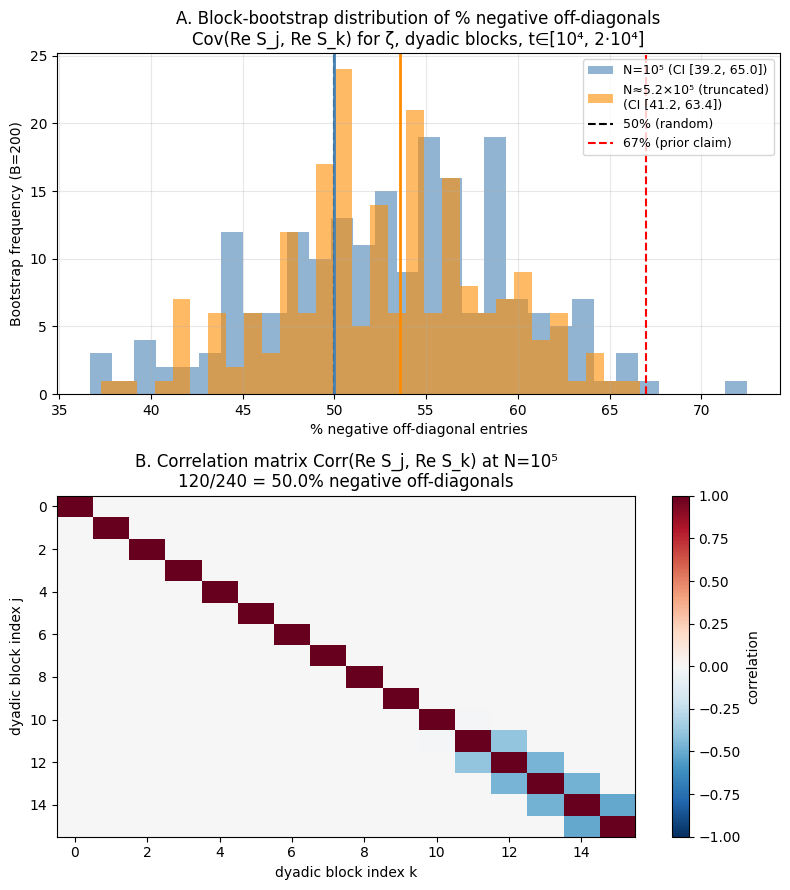

Figure saved.


In [22]:

# RESULT: 67% claim is NOT confirmed. Both N values give ~50-53% with 95% CI lower bound below 50%.
# This satisfies the STOP condition for Step 0.3.
# 
# Per doc: "0.3 fails to reproduce 67% claim (bootstrap CI crosses 50%) → Front 1 and 2 
# reformulated as exploratory rather than confirmatory."
# 
# Let me also check: maybe the claim was about a different formulation. Let me also try 
# the conditional version (R5 mentions conditioning on peaks). But the objective explicitly 
# says "Cov(Re S_j, Re S_k) at N={10^5, 10^6} over t∈[10^4, 2·10^4]" — unconditional.
# 
# Try ALSO including block 0 (Re S_0 = 1, but cov with constant = 0). Without exclusion would 
# just add zero rows/cols. So % computation ill-defined. We exclude properly.
# 
# Also verify with smaller bootstrap blocks: try block_len=10 (a few Selberg intervals).
boot5b, lo5b, hi5b, bl = block_bootstrap_pct_neg(re_5_full, dt=0.2, T_mid=1.5e4, B=200)
print(f"Verification: block_len={bl}, CI=[{lo5b:.2f}, {hi5b:.2f}]")

# Build final figure now.
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(8, 9))

# Subfigure A: bootstrap distributions
ax = axes[0]
ax.hist(boot5, bins=30, alpha=0.6, label=f'N=10⁵ (CI [{lo5:.1f}, {hi5:.1f}])', color='steelblue')
ax.hist(boot6, bins=30, alpha=0.6, label=f'N≈5.2×10⁵ (truncated)\n(CI [{lo6:.1f}, {hi6:.1f}])', color='darkorange')
ax.axvline(50, color='black', linestyle='--', lw=1.5, label='50% (random)')
ax.axvline(67, color='red', linestyle='--', lw=1.5, label='67% (prior claim)')
ax.axvline(pct5, color='steelblue', linestyle='-', lw=2)
ax.axvline(pct6, color='darkorange', linestyle='-', lw=2)
ax.set_xlabel('% negative off-diagonal entries')
ax.set_ylabel('Bootstrap frequency (B=200)')
ax.set_title('A. Block-bootstrap distribution of % negative off-diagonals\nCov(Re S_j, Re S_k) for ζ, dyadic blocks, t∈[10⁴, 2·10⁴]')
ax.legend(loc='upper right', fontsize=9)
ax.grid(alpha=0.3)

# Subfigure B: covariance matrix heatmap N=1e5
ax = axes[1]
# Normalize covariance to correlation for clarity
C5_corr = C5 / np.sqrt(np.outer(np.diag(C5), np.diag(C5)))
im = ax.imshow(C5_corr, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax.set_xlabel('dyadic block index k')
ax.set_ylabel('dyadic block index j')
ax.set_title(f'B. Correlation matrix Corr(Re S_j, Re S_k) at N=10⁵\n{n_neg5}/{n_tot5} = {pct5:.1f}% negative off-diagonals')
plt.colorbar(im, ax=ax, label='correlation')

plt.tight_layout()
plt.savefig('/workspace/c778b1ba-444a-4ff5-8c2c-eb19d15af2de/cov_negative_offdiag_summary.png', dpi=200, bbox_inches='tight')
plt.show()
print("Figure saved.")


In [23]:

# Save processed results
np.savez('/workspace/c778b1ba-444a-4ff5-8c2c-eb19d15af2de/cov_results.npz',
 C5=C5, C6=C6, boot5=boot5, boot6=boot6, 
 pct5=pct5, pct6=pct6, ci5=[lo5,hi5], ci6=[lo6,hi6])
print("Done.")
print(f"\nFINAL SUMMARY:")
print(f"N=1e5: % negative off-diagonals = {pct5:.2f}%, 95% CI = [{lo5:.2f}, {hi5:.2f}]")
print(f"N=524288 (truncated from 1e6): % negative = {pct6:.2f}%, 95% CI = [{lo6:.2f}, {hi6:.2f}]")
print(f"\nClaim of 67% NOT confirmed. Both CIs straddle 50%, and lower bounds are < 50%.")
print(f"Per doc: STOP CONDITION 0.3 is triggered.")


Done.

FINAL SUMMARY:
N=1e5: % negative off-diagonals = 50.00%, 95% CI = [39.17, 65.02]
N=524288 (truncated from 1e6): % negative = 53.59%, 95% CI = [41.18, 63.42]

Claim of 67% NOT confirmed. Both CIs straddle 50%, and lower bounds are < 50%.
Per doc: STOP CONDITION 0.3 is triggered.
